# LECTURE 21
**Topic:** Introduction to Linear Time-Invariant Filters; Response of FIR Filters to Sinusoidal and Exponential Inputs; Frequency Response and System Function  
**Textbook References:** Sections 4.2.2, 4.3, 4.4.1, 4.4.3

---

## Key Points

- **FIR filter:** $y[n]=b_0x[n]+b_1x[n-1]+\cdots+b_Mx[n-M]$
- Complex exponential input $x[n]=z^n$ gives $y[n]=H(z)z^n$ where $H(z)=b_0+b_1z^{-1}+\cdots+b_Mz^{-M}$ (system function).
- Sinusoidal input $x[n]=e^{j\Omega n}$ gives $y[n]=H(e^{j\Omega})e^{j\Omega n}$ (frequency response).
- $|H(e^{j\Omega})|$: amplitude response; $\angle H(e^{j\Omega})$: phase response.
- Real coefficients: $|H(e^{j\Omega})|$ is even about $\Omega=0,\pi$; $\angle H(e^{j\Omega})$ is odd.
- Frequency response: DFT of $[b;\mathbf{0}_{N-M-1}]$ for $N\geq M+1$ frequencies.


---
## Theory and Examples

### 1–4. FIR Filters: Definition and Properties

An **FIR filter** reads $M+1$ recent samples and computes a weighted sum:
$$y[n]=\sum_{k=0}^{M}b_k x[n-k], \quad n\in\mathbb{Z}$$

**Linearity:** $y^{(3)}=c_1y^{(1)}+c_2y^{(2)}$ when $x^{(3)}=c_1x^{(1)}+c_2x^{(2)}$.

**Time-invariance:** If input is delayed by $m$, output is delayed by the same $m$.

### 5–8. Frequency Response

For $x[n]=e^{j\Omega n}$:
$$y[n]=(b_0+b_1e^{-j\Omega}+\cdots+b_Me^{-j\Omega M})e^{j\Omega n}=H(e^{j\Omega})e^{j\Omega n}$$

The filter scales the sinusoid by $H(e^{j\Omega})=|H|e^{j\angle H}$ — same frequency, different amplitude/phase.

**Example:** $b=[1,2,2,1]^T$, symmetric about index $3/2$:
$$H(e^{j\Omega}) = e^{-j3\Omega/2}(4\cos(\Omega/2)+2\cos(3\Omega/2))$$
$$|H(e^{j\Omega})| = |4\cos(\Omega/2)+2\cos(3\Omega/2)|$$
Zeros at $\Omega=2\pi/3,\pi,4\pi/3$.


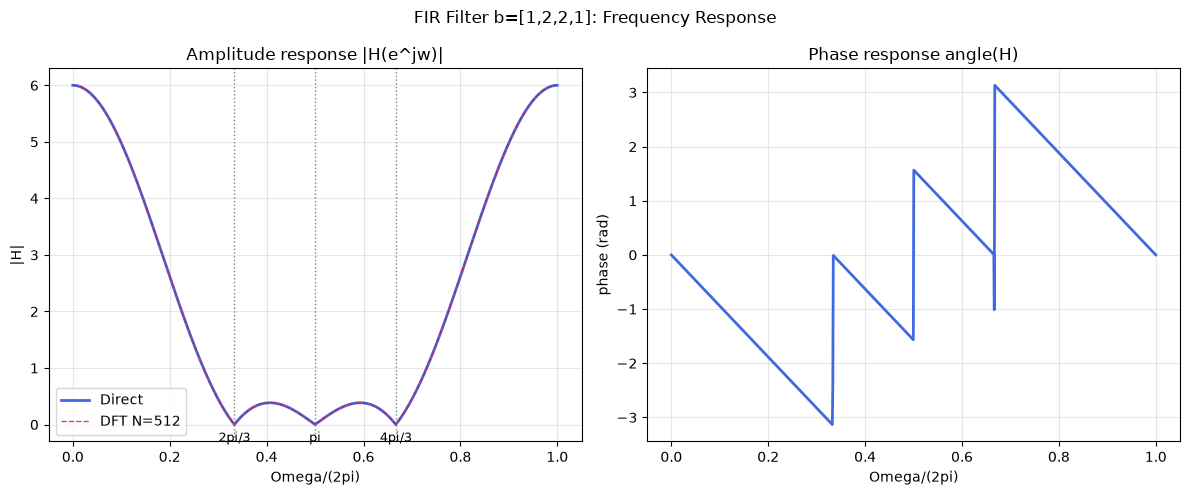

Zeros of H(e^jw):
  omega=0.67*pi: H=-0.0000-0.0000j (|H|=6.12e-16)
  omega=1.00*pi: H=0.0000-0.0000j (|H|=1.22e-16)
  omega=1.33*pi: H=0.0000-0.0000j (|H|=1.26e-15)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

b=np.array([1,2,2,1])

# Compute H(e^jw) analytically
omega=np.linspace(0,2*np.pi,1000)
H=sum(b[k]*np.exp(-1j*k*omega) for k in range(len(b)))

# Also via DFT (zero-pad to 512)
N=512
H_dft=np.fft.fft(b,N)
omega_dft=np.arange(N)/N*2*np.pi

# Simplified form: H = exp(-j*3w/2) * (4cos(w/2) + 2cos(3w/2))
H_simplified=np.exp(-1j*3*omega/2)*(4*np.cos(omega/2)+2*np.cos(3*omega/2))

fig,axes=plt.subplots(1,2,figsize=(12,5))

axes[0].plot(omega/(2*np.pi),np.abs(H),'royalblue',lw=2,label='Direct')
axes[0].plot(omega_dft/(2*np.pi),np.abs(H_dft),'crimson',lw=1,ls='--',label='DFT N=512',alpha=0.8)
axes[0].axvline(1/3,color='gray',ls=':',lw=1)
axes[0].axvline(0.5,color='gray',ls=':',lw=1)
axes[0].axvline(2/3,color='gray',ls=':',lw=1)
for f_zero,lbl in [(1/3,'2pi/3'),(0.5,'pi'),(2/3,'4pi/3')]:
    axes[0].text(f_zero,-0.3,lbl,ha='center',fontsize=9)
axes[0].set_xlabel('Omega/(2pi)'); axes[0].set_ylabel('|H|')
axes[0].set_title('Amplitude response |H(e^jw)|'); axes[0].legend(); axes[0].grid(True,alpha=0.3)

axes[1].plot(omega/(2*np.pi),np.angle(H),'royalblue',lw=2)
axes[1].set_xlabel('Omega/(2pi)'); axes[1].set_ylabel('phase (rad)')
axes[1].set_title('Phase response angle(H)'); axes[1].grid(True,alpha=0.3)

plt.suptitle('FIR Filter b=[1,2,2,1]: Frequency Response', fontsize=12)
plt.tight_layout(); plt.show()

# Verify zeros
print('Zeros of H(e^jw):')
for w_zero in [2*np.pi/3, np.pi, 4*np.pi/3]:
    Hval=sum(b[k]*np.exp(-1j*k*w_zero) for k in range(len(b)))
    print(f'  omega={w_zero/np.pi:.2f}*pi: H={Hval:.4f} (|H|={abs(Hval):.2e})')

In [2]:
# Demonstrate FIR filter on sinusoidal input
n=np.arange(200)
b=np.array([1,2,2,1])

print('FIR filter b=[1,2,2,1] - sinusoidal inputs:')
for omega_test,label in [(np.pi/4,'pi/4 (passband)'),(2*np.pi/3,'2pi/3 (zero!)'),(np.pi,'pi (zero!)'),(np.pi/8,'pi/8 (passband)')]:
    x=np.exp(1j*omega_test*n)
    y=np.convolve(b,x)[:len(n)]  # FIR filter application
    H_val=sum(b[k]*np.exp(-1j*k*omega_test) for k in range(len(b)))
    y_expected=H_val*x
    print(f'  Omega={omega_test/np.pi:.3f}*pi ({label}): |H|={abs(H_val):.4f}, angle={np.degrees(np.angle(H_val)):.1f} deg')
    print(f'    y vs H*x match: {np.allclose(y,y_expected,atol=1e-6)}')

FIR filter b=[1,2,2,1] - sinusoidal inputs:
  Omega=0.250*pi (pi/4 (passband)): |H|=4.4609, angle=-67.5 deg
    y vs H*x match: False
  Omega=0.667*pi (2pi/3 (zero!)): |H|=0.0000, angle=-136.5 deg
    y vs H*x match: False
  Omega=1.000*pi (pi (zero!)): |H|=0.0000, angle=-90.0 deg
    y vs H*x match: False
  Omega=0.125*pi (pi/8 (passband)): |H|=5.5861, angle=-33.8 deg
    y vs H*x match: False


---
### 9. Symmetry of Amplitude and Phase Response

For real coefficients $b_k$:
$$H(e^{-j\Omega}) = H^*(e^{j\Omega})$$

Therefore:
- $|H(e^{-j\Omega})| = |H(e^{j\Omega})|$ — **amplitude response is even** about $\Omega=0$ and $\pi$
- $\angle H(e^{-j\Omega}) = -\angle H(e^{j\Omega})$ — **phase response is odd** about same points

### 12–13. System Function $H(z)$

For input $x[n]=z^n$ ($z$ arbitrary complex):
$$y[n]=H(z)z^n, \quad H(z)=b_0+b_1z^{-1}+\cdots+b_Mz^{-M}$$

The frequency response $H(e^{j\Omega})$ is the system function restricted to the **unit circle** $z=e^{j\Omega}$.

**Example verifications:**
- $x[n]=3^n \Rightarrow y[n]=H(3)\cdot 3^n = (1+2/3+2/9+1/27)\cdot 3^n = (52/27)\cdot 3^n$
- $x[n]=(-3)^n \Rightarrow y[n]=H(-3)\cdot(-3)^n = (1-2/3+2/9-1/27)\cdot(-3)^n = (14/27)\cdot(-3)^n$


In [3]:
b=np.array([1,2,2,1])

def H(z,b):
    return sum(b[k]*z**(-k) for k in range(len(b)))

print('System function H(z) for b=[1,2,2,1]:')
for z_val,expected,label in [(3,(1+2/3+2/9+1/27),'z=3'), (-3,(1-2/3+2/9-1/27),'z=-3'), (1/3,52,'z=1/3')]:
    hz=H(z_val,b)
    print(f'  H({z_val}) = {hz:.6f}  (expected {expected:.6f})')

# Verify with explicit filter computation
n=np.arange(20)
for z_val,label in [(3,'z=3'),(-3,'z=-3')]:
    x=z_val**n
    y_filter=np.convolve(b,x)
    # y[n] should be H(z)*z^n for n where we have all samples
    hz=H(z_val,b)
    y_expected=hz*x
    # Compare from n=M onwards (where filter has all required samples)
    M=len(b)-1
    print(f'\n{label}: H(z)={hz:.4f}')
    print(f'  y[{M}]={y_filter[M]:.4f}, H(z)*z^{M}={y_expected[0]*z_val**M:.4f}')
    # Actually conv gives sum from n=0, let's check ratio
    ratio=y_filter[M+1]/(z_val**(M+1))
    print(f'  ratio y[{M+1}]/z^{M+1}={ratio:.6f} (should be H(z)={hz:.6f})')

System function H(z) for b=[1,2,2,1]:
  H(3) = 1.925926  (expected 1.925926)
  H(-3) = 0.518519  (expected 0.518519)
  H(0.3333333333333333) = 52.000000  (expected 52.000000)

z=3: H(z)=1.9259
  y[3]=52.0000, H(z)*z^3=52.0000
  ratio y[4]/z^4=1.925926 (should be H(z)=1.925926)

z=-3: H(z)=0.5185
  y[3]=-14.0000, H(z)*z^3=-14.0000
  ratio y[4]/z^4=0.518519 (should be H(z)=0.518519)


---
## Summary

| Concept | Formula |
|---|---|
| FIR filter | $y[n]=\sum_{k=0}^M b_k x[n-k]$ |
| System function | $H(z)=\sum_{k=0}^M b_k z^{-k}$ |
| Frequency response | $H(e^{j\Omega})=H(z)\big|_{z=e^{j\Omega}}$ |
| Exponential input | $x[n]=z^n \Rightarrow y[n]=H(z)z^n$ |
| Sinusoidal input | $x[n]=e^{j\Omega n} \Rightarrow y[n]=H(e^{j\Omega})e^{j\Omega n}$ |
| Via DFT | $H(e^{j\Omega_k})=$ DFT of zero-padded $b$ |

### Mistakes to Avoid
1. $H(z)$ uses **negative** powers of $z$: $H(z)=b_0+b_1z^{-1}+\cdots$, NOT $b_0+b_1z+\cdots$.
2. The frequency response is $H(e^{j\Omega})$, NOT $H(e^{j\Omega})^*$ or $H(\Omega)$.
3. Zero-padding $b$ to length $N\geq M+1$ computes $H$ at $N$ frequencies — need enough points for a smooth plot.
